Hubungkan Google Drive

In [8]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Import Library

In [9]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

Load Dataset

In [10]:
dataset_path = "/content/drive/MyDrive/Tugas Computer Vision/Tugas4/DataSet"

classes = ['matang', 'mentah', 'busuk']

data = []
labels = []

img_size = 100

for label, category in enumerate(classes):
    folder_path = os.path.join(dataset_path, category)

    for file in os.listdir(folder_path):
        img_path = os.path.join(folder_path, file)

        img = cv2.imread(img_path)
        img = cv2.resize(img, (img_size, img_size))

        data.append(img.flatten())
        labels.append(label)

data = np.array(data)
labels = np.array(labels)

print("Jumlah data:", len(data))

Jumlah data: 272


Split Data Training dan Testing

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    data,
    labels,
    test_size=0.2,
    random_state=42
)

print("Train :", len(X_train))
print("Test  :", len(X_test))

Train : 217
Test  : 55


Training Model KNN

In [13]:
knn = KNeighborsClassifier(n_neighbors=3)

knn.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=3)

Prediksi dan Akurasi

In [14]:
y_pred = knn.predict(X_test)

akurasi = accuracy_score(y_test, y_pred)

print("Akurasi :", akurasi * 100, "%")

Akurasi : 100.0 %


Confusion Matrix dan Report

In [15]:
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=classes))

Confusion Matrix:
[[17  0  0]
 [ 0 18  0]
 [ 0  0 20]]

Classification Report:
              precision    recall  f1-score   support

      matang       1.00      1.00      1.00        17
      mentah       1.00      1.00      1.00        18
       busuk       1.00      1.00      1.00        20

    accuracy                           1.00        55
   macro avg       1.00      1.00      1.00        55
weighted avg       1.00      1.00      1.00        55



Prediksi Gambar Baru

Prediksi : matang


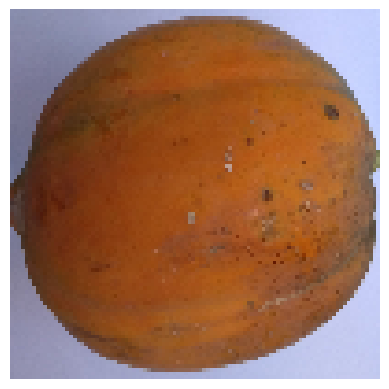

In [17]:
img_path = "/content/drive/MyDrive/Tugas Computer Vision/Tugas4/DataSet/test.jpg"

img = cv2.imread(img_path)
img = cv2.resize(img, (100,100))

test = np.array([img.flatten()])

hasil = knn.predict(test)

print("Prediksi :", classes[hasil[0]])

plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

Export Semua Dataset ke Excel

In [24]:
import pandas as pd

kelas = ['matang', 'mentah', 'busuk']

pred_all = knn.predict(data)

hasil = []

for i in range(len(pred_all)):

    hasil.append([
        i+1,
        f"Gambar_{i+1}.jpg",
        kelas[labels[i]],
        kelas[pred_all[i]],
        "Benar" if labels[i] == pred_all[i] else "Salah"
    ])

df = pd.DataFrame(hasil, columns=[
    'No',
    'Nama File',
    'Data Asli',
    'Prediksi',
    'Status'
])

df.to_excel('/content/drive/MyDrive/Tugas Computer Vision/Tugas4/Hasil/Hasil_Klasifikasi_Pepaya.xlsx', index=False)

print("Berhasil simpan seluruh data")

Berhasil simpan seluruh data
